# Notebook 3. Kernel statistics as the only covariates

**Question.** Can the kernel statistics `A_t`, `S_t` and `R_t`, read at a step before any run groks, predict when a run will grok?

Notebooks 1 and 2 also gave the models the settings (`alpha`, width and weight decay). The settings are a shortcut. The 5 seeds of one cell behave almost the same, so a model can learn the typical grokking step of each cell without using the kernel. Here the models see only the kernel statistics, read at the prediction time $t^* = 2{,}430$. The Terminology section defines each term, and the Evaluation design section gives the full procedure.

**Test.** We hold out one value of `alpha` at a time, fit on the other two, and predict the held-out runs.

**Models, from simplest to most flexible.**
1. A log-normal AFT model, linear in the three standardised statistics.
2. The same model with the three pairwise interaction terms:
$$\log T = \beta_0 + \beta_A z_A + \beta_S z_S + \beta_R z_R + \gamma_{AS}\, z_A z_S + \gamma_{AR}\, z_A z_R + \gamma_{SR}\, z_S z_R + \sigma\varepsilon, \qquad \varepsilon \sim N(0, 1).$$
Each interaction term is the product of two standardised statistics. A non-zero $\gamma_{AS}$ means that the slope of $\log T$ in $z_A$ changes by $\gamma_{AS}$ for each standard deviation of $z_S$, and the reverse. The model has no squared terms and no three-way term.
3. Two non-linear models of the cross-sectional covariates: kernel ridge regression and XGBoost.
4. Two models of the longitudinal covariates (Part 5): XGBoost and a GRU recurrent network.

**Short answer.**
- Each statistic alone ranks runs from a held-out `alpha` about as well as chance (mean concordance 0.50 to 0.55).
- The linear AFT scores 0.550, and interaction terms lift it to 0.631. Alignment speeds grokking most when the kernel has rotated ($\gamma_{AR} = -0.49$) and when it has grown little ($\gamma_{AS} = +0.61$).
- XGBoost, with hyperparameters chosen on a validation set, scores 0.737 on average over 5 seeds (0.720 to 0.760). The relation is non-linear.
- The kernel statistics are strongly autocorrelated over training. A GRU on the longitudinal covariates scores 0.765, about 0.02 above XGBoost on the cross-sectional covariates over the same 3 seeds (0.744).
- XGBoost on width and weight decay alone scores 0.778. On a held-out `alpha`, no kernel model beats a flexible model of the settings.

## Terminology

| Term | Definition |
| --- | --- |
| grokking step `T` | The first saved step at which test accuracy reaches 0.95 (report §3.5). |
| right-censored run | A run that does not reach 0.95 within its budget of 200,000 steps. We know only that `T` > 200,000. Censored runs are kept in every model that can use them. |
| cell | One combination of `alpha`, width and weight decay. Each cell holds 5 seeds. |
| kernel statistics | `S_t`, `R_t` and `A_t`: the growth, rotation and label alignment of the empirical kernel at step t (report Eq. 6). We write $x(t) = (A_t, S_t, R_t)$. |
| standardised statistic | A statistic minus its mean over the training runs, divided by its standard deviation. We write $z_A$, $z_S$, $z_R$. |
| prediction time $t^*$ | The step at which the kernel is read to predict `T`. Here $t^* = 2{,}430$, earlier than every grokking step, so no prediction uses information from after grokking. Survival analysis calls this the landmark time. |
| cross-sectional covariates | The three statistics at the single step $t^*$, that is $x(t^*)$. Parts 1 to 4 use only these. |
| longitudinal covariates | The statistics at every saved step $s \le t^*$, that is the history $\{x(s) : s \le t^*\}$. There are 25 saved steps, spaced roughly geometrically from 0 to 2,430. For each run this is a short multivariate time series. Part 5 uses it. |
| interaction term | The product of two standardised statistics: $z_A z_S$, $z_A z_R$ or $z_S z_R$. Its coefficient $\gamma$ measures how much the effect of one statistic on $\log T$ changes per unit of the other. |
| autocorrelation at lag k | The correlation between a time series and the same series shifted by k saved steps. |
| AFT model | Accelerated failure time model. A regression of $\log T$ on covariates with normal errors, in which a censored run contributes the probability that $\log T$ exceeds its censoring time. |
| concordance index | Harrell's C. Over all pairs of runs whose order of grokking is known, the share that the model orders correctly. 0.5 is chance and 1 is perfect. |
| hyperparameter | A setting of a model that is fixed before fitting, such as tree depth or learning rate. |
| validation set | Runs taken out of the training runs and used only to choose hyperparameters. They are never the test runs. |

## Evaluation design

**Two different splits.** The word "split" means two things in this project.

1. *Inside each grokking run.* The network trains on 90% of the 529 pairs (a, b) and is tested on the other 53. This split defines the grokking step `T` through test accuracy. The kernel statistics are computed on the 53 test pairs. Every run uses the same split (data seed 42). The report gives each seed its own split (§3.1), so this is a known gap.
2. *Across runs.* This is the split for the statistical models in this notebook. The rest of this section is about it.

**No single train/test split.** The runs come in cells of 5 seeds, and the seeds of one cell are near copies. A random split of runs would put seeds of the same cell on both sides. The test score would then mostly measure how well the model remembers each cell. We therefore use grouped cross-validation: a whole group of runs is held out together, and every run is predicted exactly once by a model that never saw its group.

**Outer loop: leave one `alpha` out.** There are three folds. Each fold fits on the runs with two values of `alpha` and predicts the runs with the third. The model has never seen a run with the held-out `alpha`, so this measures extrapolation to a new kind of run. We report the concordance index on each held-out `alpha` and the mean of the three. Part 2 is the exception. It fits on all 630 runs to describe association, and it makes no claim about prediction.

**Inner loop: hyperparameter selection.** Hyperparameters are always chosen from the training runs of a fold. The held-out `alpha` is never used to choose them.

- *XGBoost.* We hold out 20% of the training cells, drawn at random, as a validation set. For each of 24 settings in a grid (tree depth 1, 2, 3 or 4; learning rate 0.03 or 0.1; minimum child weight 1, 5 or 10) we fit on the remaining 80% of the training cells. Boosting stops once the validation AFT loss has not improved for 50 rounds, with at most 1,000 rounds. We keep the setting with the highest validation concordance, then refit it on all training runs with the chosen number of rounds. The subsample rate is fixed at 0.8.
- *Kernel ridge regression.* The penalty (0.01, 0.1 or 1) and the RBF width (0.1, 0.5 or 2) are chosen by 5-fold grouped cross-validation over the cells of the training runs.
- *Linear AFT models.* There is nothing to tune. A small fixed ridge penalty of 0.01 keeps the fit stable.
- *GRU network (Part 5).* The architecture, learning rate and weight decay are fixed in advance. The number of training epochs is chosen by early stopping on a validation set of 20% of the training cells.

**Scaling.** Every standardisation uses the means and standard deviations of the training runs only.

**Seeds.** The seed controls the validation draw, the row subsampling of XGBoost and the initial weights of the GRU. We repeat XGBoost over 5 seeds and the Part 5 models over 3 seeds, and report the spread.

## Setup

In [1]:
import copy
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import chi2
from lifelines import LogNormalAFTFitter
from lifelines.utils import concordance_index
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, GroupKFold

plt.style.use('fitting.mplstyle')
GREY, INK = '#8a8984', '#0b0b0b'
KERNEL_COLOURS = {'A_t': '#7b5cd6', 'S_t': '#1a9e8f', 'R_t': '#c99a06'}
kernel = ['A_t', 'S_t', 'R_t']
pairs = [('A_t', 'S_t'), ('A_t', 'R_t'), ('S_t', 'R_t')]
T_STAR = 2_430     # prediction time t*

## Load the data

The same runs as notebook 2: every weight decay level up to 1e-3, so 630 runs.

In [2]:
runs = pd.read_parquet('data/runs.parquet', columns=['run_id', 'alpha', 'width', 'eta_kappa', 'seed', 'last_step'])
acc = pd.read_parquet('data/checkpoints.parquet', columns=['run_id', 'step', 'train_acc', 'test_acc'])
kern = pd.read_parquet('data/report_kernel.parquet')

events = runs.set_index('run_id')
events['t_gen95'] = acc[acc['test_acc'] >= 0.95].groupby('run_id')['step'].min()
events = events.reset_index()
events['grokked'] = events['t_gen95'].notna().astype(int)     # 1 = grokked, 0 = censored
events['T'] = events['t_gen95'].fillna(events['last_step'])    # the grokking step, or 200,000 if censored
events['cell'] = (events['alpha'].astype(str) + '_' + events['width'].astype(str) + '_'
                  + events['eta_kappa'].map('{:g}'.format))

data = events.merge(kern[kern['step'] == T_STAR].drop(columns='step'), on='run_id')
data = data[data['eta_kappa'] <= 1e-3].reset_index(drop=True)
assert data['T'].min() > T_STAR     # no run has grokked when we read the kernel
pd.Series({'runs': len(data), 'grokked': data['grokked'].sum(), 'censored': (1 - data['grokked']).sum()})

runs        630
grokked     355
censored    275
dtype: int64

## Part 1. The kernel statistics at the prediction time $t^*$

Each dot is one run. Filled dots grokked, and their height is the grokking step. Hollow dots at the top never grokked.

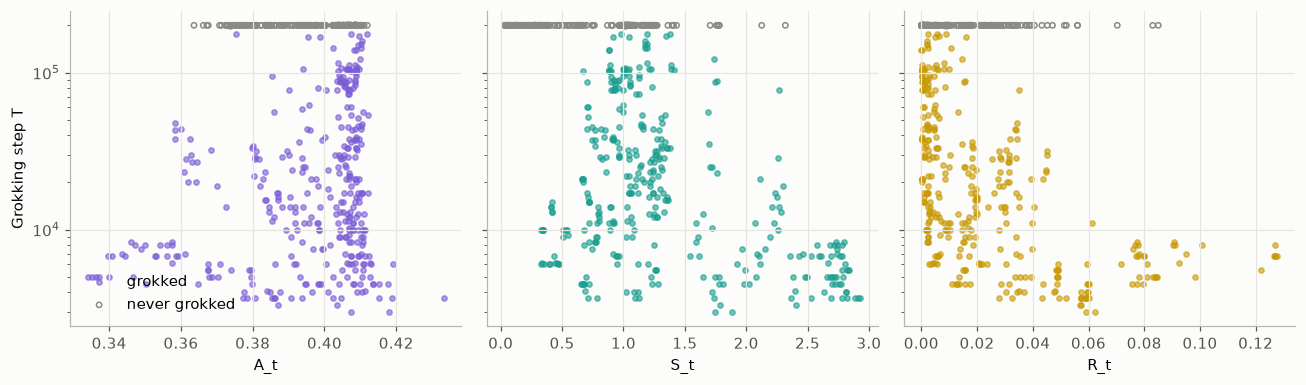

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, number in zip(axes, kernel):
    g, c = data[data['grokked'] == 1], data[data['grokked'] == 0]
    ax.scatter(g[number], g['T'], s=12, color=KERNEL_COLOURS[number], alpha=0.6, label='grokked')
    ax.scatter(c[number], c['T'], s=12, facecolors='none', edgecolors=GREY, label='never grokked')
    ax.set_yscale('log')
    ax.set_xlabel(number)
axes[0].set_ylabel('Grokking step T')
axes[0].legend(loc='lower left')
plt.tight_layout()
plt.show()

The three numbers also move together. A correlation near 1 or -1 means two numbers say almost the same thing.

In [4]:
data[kernel].corr().round(2)

,A_t,S_t,R_t
A_t,1.00,-0.38,-0.68
S_t,-0.38,1.00,0.55
R_t,-0.68,0.55,1.00


And here is how they differ between the values of `alpha`. If one `alpha` sits in its own corner, a model trained on the other two has to stretch to reach it.

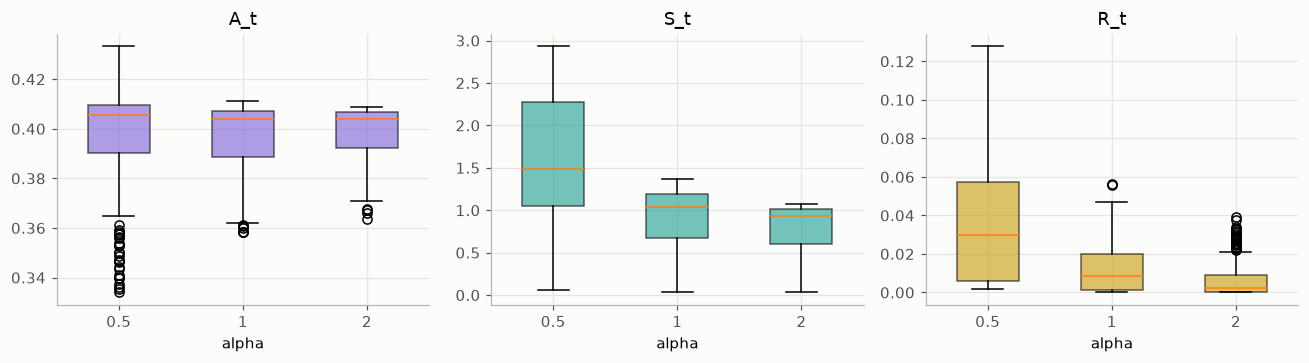

,A_t,S_t,R_t
alpha,,,
0.5,0.405,1.487,0.030
1.0,0.404,1.039,0.008
2.0,0.404,0.930,0.002


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, number in zip(axes, kernel):
    box = ax.boxplot([g[number] for _, g in data.groupby('alpha')], tick_labels=['0.5', '1', '2'], patch_artist=True, widths=0.5)
    for patch in box['boxes']:
        patch.set_facecolor(KERNEL_COLOURS[number])
        patch.set_alpha(0.6)
    ax.set_xlabel('alpha')
    ax.set_title(number)
plt.tight_layout()
plt.show()
data.groupby('alpha')[kernel].median().round(3)

**Takeaway**
- `A_t` and `R_t` move together strongly (correlation -0.68), so the model can struggle to split their effects.
- `A_t` looks the same for every `alpha` at $t^*$ (median 0.40). `S_t` and `R_t` are smaller for bigger `alpha`, since a lazier network moves its kernel less.
- At `alpha` 2 the kernel has barely moved (median `R_t` 0.002). A model trained on `alpha` 0.5 and 1 has to guess outside what it has seen.

## Part 2. Which numbers matter, and how sure are we?

We fit the AFT on all 630 runs. The AFT is linear regression on log `T` that also uses "at least 200,000" for the runs that never grok (report Eq. 10). Each number is scaled to mean 0 and spread 1, so the coefficients compare fairly. A coefficient `a` multiplies the median grokking step by e^a for one spread more of that number. A negative `a` means sooner.

We fit it twice: with the three numbers alone, and with the three interactions added.

In [6]:
z = (data[kernel] - data[kernel].mean()) / data[kernel].std()
X_main = z.copy()
X_inter = z.copy()
for a, b in pairs:
    X_inter[f'{a} × {b}'] = z[a] * z[b]

fit_main = LogNormalAFTFitter().fit(X_main.assign(T=data['T'], grokked=data['grokked']), 'T', 'grokked')
fit_inter = LogNormalAFTFitter().fit(X_inter.assign(T=data['T'], grokked=data['grokked']), 'T', 'grokked')
table = fit_inter.summary.loc['mu_'].drop('Intercept')[['coef', 'exp(coef)', 'p']]
table.columns = ['coef a', 'times the median', 'p']
table.round(3)

,coef a,times the median,p
covariate,,,
A_t,-0.654,0.520,0.000
A_t × R_t,-0.490,0.613,0.000
A_t × S_t,0.609,1.839,0.000
R_t,-0.837,0.433,0.000
S_t,-0.728,0.483,0.000
S_t × R_t,-0.097,0.908,0.386


### Do the interactions help?

The likelihood ratio test asks if the extra three terms fit the data better than chance would allow.

In [7]:
lr = 2 * (fit_inter.log_likelihood_ - fit_main.log_likelihood_)
pd.Series({'LR statistic': lr, 'extra terms': 3, 'p': chi2.sf(lr, 3)}).round(4)

LR statistic    37.8555
extra terms      3.0000
p                0.0000
dtype: float64

### A fairer error bar

The p-values above treat all 630 runs as independent. They aren't: the 5 seeds of a cell are near copies. So we redo the fit 300 times, each time drawing whole cells at random with replacement. The spread of the coefficients over those fits gives an honest 95% range.

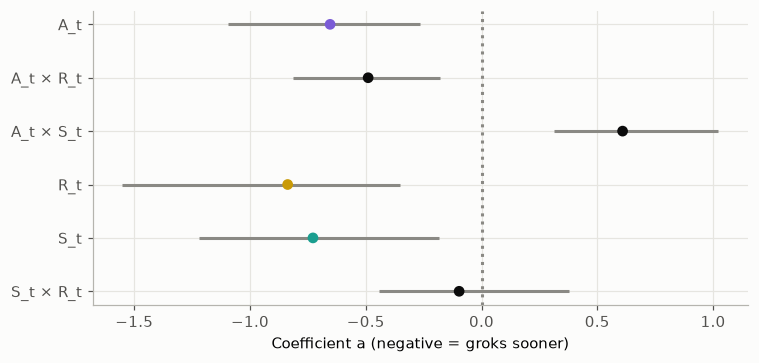

,coef a,lower 95%,upper 95%,range excludes 0
covariate,,,,
A_t,-0.654,-1.094,-0.267,True
A_t × R_t,-0.490,-0.816,-0.178,True
A_t × S_t,0.609,0.315,1.022,True
R_t,-0.837,-1.551,-0.354,True
S_t,-0.728,-1.222,-0.183,True
S_t × R_t,-0.097,-0.442,0.378,False


In [8]:
rng = np.random.default_rng(0)
cells = data['cell'].unique()
boot = []
for _ in range(300):
    pick = rng.choice(cells, size=len(cells), replace=True)
    rows = np.concatenate([np.flatnonzero(data['cell'] == c) for c in pick])
    f = LogNormalAFTFitter(penalizer=1e-4).fit(X_inter.iloc[rows].reset_index(drop=True).assign(T=data['T'].iloc[rows].to_numpy(), grokked=data['grokked'].iloc[rows].to_numpy()), 'T', 'grokked')
    boot.append(f.params_.loc['mu_'].drop('Intercept'))
boot = pd.DataFrame(boot)
ranges = pd.DataFrame({'coef a': table['coef a'], 'lower 95%': boot.quantile(0.025), 'upper 95%': boot.quantile(0.975)})
ranges['range excludes 0'] = (ranges['lower 95%'] > 0) | (ranges['upper 95%'] < 0)

fig, ax = plt.subplots(figsize=(7, 3.4))
colours = [KERNEL_COLOURS.get(name, INK) for name in ranges.index]
ax.errorbar(ranges['coef a'], range(len(ranges)), xerr=[ranges['coef a'] - ranges['lower 95%'], ranges['upper 95%'] - ranges['coef a']],
            fmt='none', ecolor=GREY)
ax.scatter(ranges['coef a'], range(len(ranges)), color=colours, zorder=3)
ax.axvline(0, color=GREY, linestyle=':')
ax.set_yticks(range(len(ranges)), ranges.index)
ax.invert_yaxis()
ax.set_xlabel('Coefficient a (negative = groks sooner)')
plt.tight_layout()
plt.show()
ranges.round(3)

### What each interaction does

An interaction is easiest to read as a family of curves. Each panel varies one statistic from 2 standard deviations below its mean to 2 above. It does so at three fixed values of a second statistic: one standard deviation below its mean, at its mean, and one above. The third statistic stays at its mean, so the two interaction terms that contain it are zero. The curves are the predicted median grokking step from the AFT model with interactions, fitted on all runs.

If the three curves are parallel on the log scale, the pair does not interact. If they fan out or cross, the effect of the first statistic depends on the second. The panel title gives the fitted coefficient $\gamma$ of that pair.

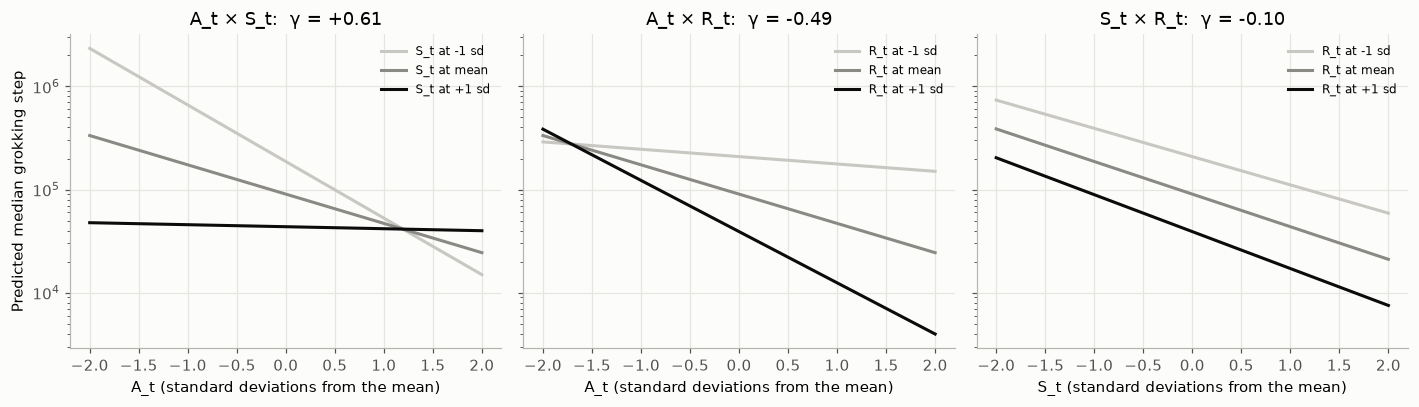

In [9]:
grid = np.linspace(-2, 2, 50)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (a, b) in zip(axes, pairs):
    for level, shade, label in zip([-1, 0, 1], ['#c8c7c2', GREY, INK], ['-1 sd', 'mean', '+1 sd']):
        probe = pd.DataFrame(0.0, index=range(len(grid)), columns=kernel)
        probe[a], probe[b] = grid, level
        for p, q in pairs:
            probe[f'{p} × {q}'] = probe[p] * probe[q]
        ax.plot(grid, fit_inter.predict_median(probe[list(X_inter)]).to_numpy().ravel(), color=shade, label=f'{b} at {label}')
    ax.set_title(f'{a} × {b}:  γ = {table.loc[f"{a} × {b}", "coef a"]:+.2f}')
    ax.set_yscale('log')
    ax.set_xlabel(f'{a} (standard deviations from the mean)')
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('Predicted median grokking step')
plt.tight_layout()
plt.show()

**Takeaway**
- All three main coefficients are negative. At the mean of the other statistics, a run whose kernel has grown more, rotated more, or aligned better with the labels groks sooner.
- Together the three interaction terms improve the fit (likelihood ratio 37.9 on 3 degrees of freedom, p < 0.0001). The cell bootstrap ranges exclude 0 for every term except $z_S z_R$.
- $z_A z_S$ ($\gamma_{AS} = +0.61$). Alignment matters most when the kernel has grown little. With `S_t` one standard deviation below its mean, moving `A_t` from 2 standard deviations below its mean to 2 above lowers the predicted median about 150 times. With `S_t` one standard deviation above its mean, the curve is almost flat.
- $z_A z_R$ ($\gamma_{AR} = -0.49$). Alignment matters most when the kernel has rotated. With `R_t` one standard deviation above its mean, the same change in `A_t` lowers the predicted median about 100 times. With `R_t` one standard deviation below, it lowers it about 2 times.
- $z_S z_R$ ($\gamma_{SR} = -0.10$, p = 0.39). The three curves are close to parallel, so growth and rotation act separately.
- These are associations across all runs, and they make no claim about prediction. Medians above 200,000 lie beyond the step budget and are extrapolations. Part 3 tests prediction on held-out runs.
- Products of correlated statistics can also stand in for curvature. Notebook 4 (Part 6) separates the two.

## Part 3. Can it predict an `alpha` it has never seen?

Now the real test. For each value of `alpha` we train on the other two and predict the hidden one. The scaling of the numbers is learned from the training runs only.

We start with the two linear AFTs and each number on its own.

In [10]:
linear_models = {'A_t only': ['A_t'], 'S_t only': ['S_t'], 'R_t only': ['R_t'],
                 'linear AFT': list(X_main), 'linear AFT + interactions': list(X_inter)}
pred = pd.DataFrame(index=data.index)
for a in sorted(data['alpha'].unique()):
    train, test = data['alpha'] != a, data['alpha'] == a
    z = (data[kernel] - data.loc[train, kernel].mean()) / data.loc[train, kernel].std()
    X = z.copy()
    for p, q in pairs:
        X[f'{p} × {q}'] = z[p] * z[q]
    for name, cols in linear_models.items():
        aft = LogNormalAFTFitter(penalizer=0.01).fit(X.loc[train, cols].assign(T=data['T'], grokked=data['grokked']), 'T', 'grokked')
        pred.loc[test, name] = aft.predict_median(X.loc[test, cols]).to_numpy().ravel()

### The non-linear models

A linear model, even with interaction terms, can only bend in the few ways its terms allow. These two models can fit a general smooth or piecewise shape.

- **Kernel ridge regression** fits a smooth surface in the space of an RBF kernel. It predicts $\log T$, so like ordinary regression it only uses runs that grokked. Its two hyperparameters are chosen by grouped cross-validation inside the training runs.
- **XGBoost** is a sum of small regression trees, each fitted to the errors of the trees before it. Its `survival:aft` objective uses the same likelihood as our AFT model, so it keeps the censored runs. Its hyperparameters are chosen on a validation set of training cells (see Evaluation design). The table below lists the setting chosen in each fold.

In [11]:
XGB_BASE = {'objective': 'survival:aft', 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.0,
            'subsample': 0.8, 'eval_metric': 'aft-nloglik'}
XGB_GRID = [{'max_depth': d, 'eta': e, 'min_child_weight': w} for d, e, w in itertools.product([1, 2, 3, 4], [0.03, 0.1], [1, 5, 10])]
log_T = np.log(data['T'])
upper = np.where(data['grokked'] == 1, data['T'], np.inf)     # XGBoost takes the raw step. A censored run's T can be anything above 200,000.


def validation_split(train, seed):
    # Hold out 20% of the training cells as a validation set. Returns the fitting rows and the validation rows.
    cells = data.loc[train, 'cell'].unique()
    held = np.random.default_rng(seed).choice(cells, round(0.2 * len(cells)), replace=False)
    val = train & data['cell'].isin(held).to_numpy()
    return train & ~val, val


def aft_matrix(X, rows):
    m = xgb.DMatrix(X[rows])
    m.set_float_info('label_lower_bound', data['T'].to_numpy()[rows])
    m.set_float_info('label_upper_bound', upper[rows])
    return m


def tuned_xgb(X, train, seed):
    # Choose the hyperparameters on a validation set of cells, then refit on all training runs.
    fit, val = validation_split(train, seed)
    best = (-1, None, None)
    for setting in XGB_GRID:
        params = {**XGB_BASE, **setting, 'seed': seed}
        booster = xgb.train(params, aft_matrix(X, fit), 1000, evals=[(aft_matrix(X, val), 'validation')],
                            early_stopping_rounds=50, verbose_eval=False)
        rounds = booster.best_iteration + 1
        c = concordance_index(data['T'].to_numpy()[val], booster.predict(aft_matrix(X, val), iteration_range=(0, rounds)),
                              data['grokked'].to_numpy()[val])
        if c > best[0]:
            best = (c, params, rounds)
    return xgb.train(best[1], aft_matrix(X, train), best[2]), best


chosen = {}
for a in sorted(data['alpha'].unique()):
    train, test = (data['alpha'] != a).to_numpy(), (data['alpha'] == a).to_numpy()
    z = (data[kernel] - data.loc[train, kernel].mean()) / data.loc[train, kernel].std()

    g = train & (data['grokked'] == 1).to_numpy()
    krr = GridSearchCV(KernelRidge(kernel='rbf'), {'alpha': [0.01, 0.1, 1], 'gamma': [0.1, 0.5, 2]}, cv=GroupKFold(5))
    krr.fit(z[g], log_T[g], groups=data.loc[g, 'cell'])
    pred.loc[test, 'kernel ridge'] = np.exp(krr.predict(z[test]))

    booster, best = tuned_xgb(z.to_numpy(), train, seed=0)
    pred.loc[test, 'XGBoost'] = booster.predict(xgb.DMatrix(z.to_numpy()[test]))
    chosen[f'alpha {a:g} held out'] = {'XGBoost depth': best[1]['max_depth'], 'learning rate': best[1]['eta'],
                                       'min child weight': best[1]['min_child_weight'], 'rounds': best[2],
                                       'validation concordance': round(best[0], 3),
                                       'kernel ridge penalty': krr.best_params_['alpha'], 'kernel ridge gamma': krr.best_params_['gamma']}
pd.DataFrame(chosen).T

,XGBoost depth,learning rate,min child weight,rounds,validation concordance,kernel ridge penalty,kernel ridge gamma
alpha 0.5 held out,1.0,0.03,10.0,295.0,0.806,0.01,0.1
alpha 1 held out,3.0,0.10,5.0,126.0,0.917,0.01,0.1
alpha 2 held out,4.0,0.03,10.0,470.0,0.805,0.01,0.1


### The scores

We score each hidden `alpha` on its own, then take the mean of the three. For reference, notebook 2 got **0.549** on the same test from a linear AFT on width and weight decay. The dashed line marks it. Part 5 adds a flexible model of the settings, which is a stronger reference.

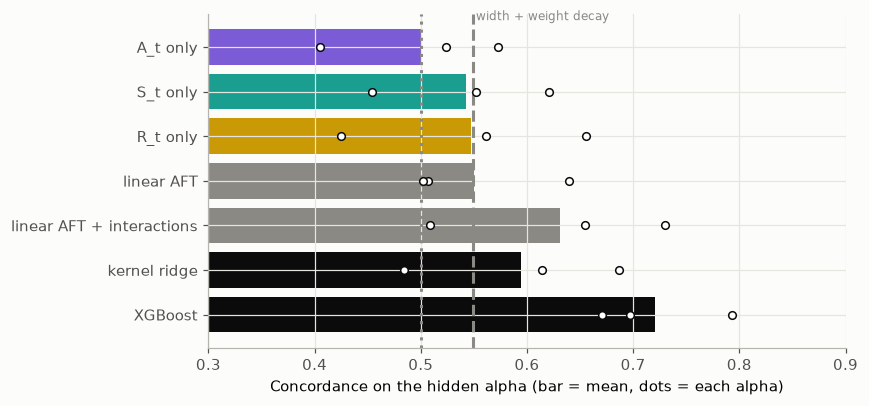

,alpha 0.5,alpha 1,alpha 2,mean
A_t only,0.573,0.524,0.405,0.501
S_t only,0.621,0.552,0.454,0.542
R_t only,0.655,0.561,0.425,0.547
linear AFT,0.639,0.507,0.503,0.550
linear AFT + interactions,0.730,0.509,0.654,0.631
kernel ridge,0.686,0.614,0.484,0.595
XGBoost,0.697,0.671,0.793,0.720


In [12]:
scores = {}
for name in pred:
    scores[name] = {f'alpha {a:g}': concordance_index(data.loc[data['alpha'] == a, 'T'], pred.loc[data['alpha'] == a, name],
                                                      data.loc[data['alpha'] == a, 'grokked'])
                    for a in sorted(data['alpha'].unique())}
scores = pd.DataFrame(scores).T
scores['mean'] = scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 3.8))
colours = [KERNEL_COLOURS['A_t'], KERNEL_COLOURS['S_t'], KERNEL_COLOURS['R_t'], GREY, GREY, INK, INK]
ax.barh(scores.index, scores['mean'], color=colours)
for i, (name, row) in enumerate(scores.iterrows()):
    ax.scatter(row[['alpha 0.5', 'alpha 1', 'alpha 2']], [i] * 3, color='white', edgecolors=INK, s=25, zorder=3)
ax.axvline(0.5, color=GREY, linestyle=':')
ax.axvline(0.549, color=GREY, linestyle='--')
ax.text(0.552, -0.6, 'width + weight decay', color=GREY, fontsize=8)
ax.set_xlim(0.3, 0.9)
ax.invert_yaxis()
ax.set_xlabel('Concordance on the hidden alpha (bar = mean, dots = each alpha)')
plt.tight_layout()
plt.show()
scores.round(3)

### Is the XGBoost score stable across seeds?

The seed sets the validation draw and the row subsampling. We rerun the whole procedure, hyperparameter selection included, with 5 seeds.

In [13]:
seed_scores = {}
for seed in range(5):
    row = {}
    for a in sorted(data['alpha'].unique()):
        train, test = (data['alpha'] != a).to_numpy(), (data['alpha'] == a).to_numpy()
        z = ((data[kernel] - data.loc[train, kernel].mean()) / data.loc[train, kernel].std()).to_numpy()
        booster, _ = tuned_xgb(z, train, seed)
        row[f'alpha {a:g}'] = concordance_index(data.loc[test, 'T'], booster.predict(xgb.DMatrix(z[test])), data.loc[test, 'grokked'])
    seed_scores[f'seed {seed}'] = row
seed_scores = pd.DataFrame(seed_scores).T
seed_scores['mean'] = seed_scores.mean(axis=1)
seed_scores.round(3)

,alpha 0.5,alpha 1,alpha 2,mean
seed 0,0.697,0.671,0.793,0.720
seed 1,0.745,0.678,0.858,0.760
seed 2,0.743,0.679,0.834,0.752
seed 3,0.740,0.637,0.806,0.728
seed 4,0.717,0.647,0.809,0.724


**Takeaway**
- Single statistics are near chance on average. Each one helps on one `alpha` and fails on another.
- The linear AFT (0.550) matches the linear AFT on width and weight decay (0.549). Interaction terms lift it to 0.631.
- These models include the censored runs. Notebook 4 (Part 6) shows that interaction terms help mostly by separating runs that grok from runs that never do.
- Kernel ridge (0.595) fails on `alpha` 2 (0.484). It uses grokked runs only, and `alpha` 2 lies at the edge of the training data.
- XGBoost with seed 0 scores 0.720 and is the best model on every held-out `alpha`. The relation between the kernel statistics and grokking is non-linear.
- Over 5 seeds XGBoost scores 0.720 to 0.760, with a mean of 0.737. The fixed settings used in an earlier version of this notebook (depth 3, learning rate 0.05, 300 rounds) gave 0.738 to 0.753. Choosing the hyperparameters on a validation set did not improve the score.
- The chosen hyperparameters differ between folds. Depth 1 is chosen when `alpha` 0.5 is held out, and depth 3 or 4 otherwise. The validation concordance (0.81 to 0.92) is far above the test concordance. The validation cells come from the training values of `alpha`, so the validation score measures fit within known `alpha` values, while the test score measures extrapolation.

## Part 4. What shape did XGBoost find?

We fit XGBoost once on all runs, with hyperparameters chosen on a validation set of 20% of the cells. Then we vary one statistic from low to high, hold the other two at their median, and plot the predicted grokking step. This is a one-dimensional slice of the fitted function. A flat line means the statistic has no effect at the median of the others.

chosen: {'max_depth': 3, 'eta': 0.03, 'min_child_weight': 1} rounds: 239


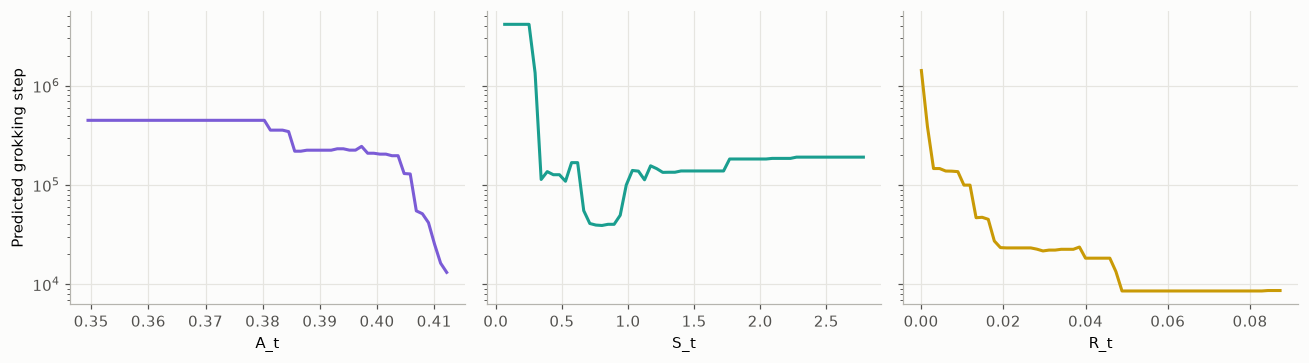

In [14]:
z = (data[kernel] - data[kernel].mean()) / data[kernel].std()
booster, best = tuned_xgb(z.to_numpy(), np.ones(len(data), dtype=bool), seed=0)
print('chosen:', {k: best[1][k] for k in ['max_depth', 'eta', 'min_child_weight']}, 'rounds:', best[2])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, number in zip(axes, kernel):
    grid = np.linspace(z[number].quantile(0.02), z[number].quantile(0.98), 60)
    probe = pd.DataFrame({c: np.full(60, z[c].median()) for c in kernel})
    probe[number] = grid
    ax.plot(grid * data[number].std() + data[number].mean(), booster.predict(xgb.DMatrix(probe.to_numpy())), color=KERNEL_COLOURS[number])
    ax.set_yscale('log')
    ax.set_xlabel(number)
axes[0].set_ylabel('Predicted grokking step')
plt.tight_layout()
plt.show()

### Two numbers at once

This map holds `A_t` at its median and varies `S_t` and `R_t` together. Darker means a later grokking step. If the colour bands run straight across, the two numbers act separately. If they bend, the effect of one depends on the other, which is an interaction.

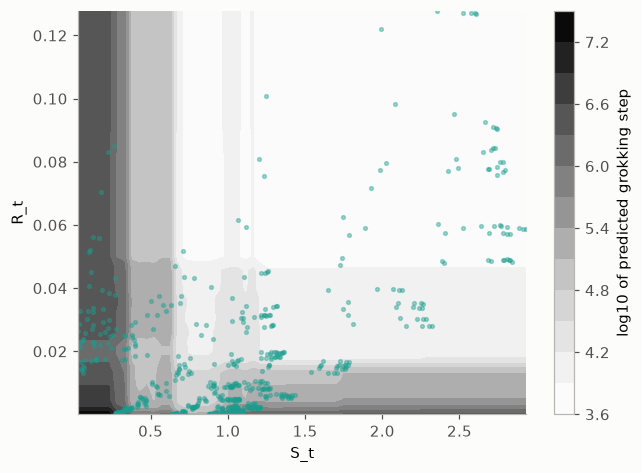

In [15]:
s_grid = np.linspace(z['S_t'].min(), z['S_t'].max(), 60)
r_grid = np.linspace(z['R_t'].min(), z['R_t'].max(), 60)
S, R = np.meshgrid(s_grid, r_grid)
probe = pd.DataFrame({'A_t': z['A_t'].median(), 'S_t': S.ravel(), 'R_t': R.ravel()})
surface = booster.predict(xgb.DMatrix(probe.to_numpy())).reshape(S.shape)

fig, ax = plt.subplots(figsize=(6, 4.4))
im = ax.contourf(S * data['S_t'].std() + data['S_t'].mean(), R * data['R_t'].std() + data['R_t'].mean(), np.log10(surface), levels=12, cmap='Greys')
ax.scatter(data['S_t'], data['R_t'], s=6, color=KERNEL_COLOURS['S_t'], alpha=0.4)
fig.colorbar(im, label='log10 of predicted grokking step')
ax.set_xlabel('S_t')
ax.set_ylabel('R_t')
ax.grid(False)
plt.tight_layout()
plt.show()

**Takeaway**
- `S_t` has an interior optimum. Kernels that shrank (`S_t` below about 0.3) are predicted never to grok. Runs with `S_t` between about 0.7 and 1.0 are predicted to grok earliest. Above 1.0 the predicted step rises again.
- `R_t` near 0 means late grokking. The predicted step falls more than 100 times by `R_t` = 0.05 and is flat after that.
- Higher `A_t` means sooner, almost entirely above 0.40.
- On the map, early grokking needs both `S_t` above about 0.65 and `R_t` above about 0.005. Needing both is an interaction. It mostly separates runs that never grok from the rest, which matches notebook 4 (Part 6).
- The steps in the curves come from tree splits, so small wiggles carry no meaning. Predicted steps above 200,000 lie beyond the step budget, and only their order matters.

## Part 5. Do the longitudinal covariates add information?

Parts 2 to 4 use the cross-sectional covariates $x(t^*)$. The kernel was also saved at 24 earlier steps, so each run also has longitudinal covariates: the series $x(s)$ at the 25 saved steps $s \le t^*$. If this history carries information that $x(t^*)$ lacks, a model of the history should rank runs better. A recurrent neural network is the standard model for such a series.

We first check whether the series is autocorrelated. The saved steps are spaced roughly geometrically, so lag 1 means the previous saved step. Near $t^*$ that step is about 1.36 times earlier. For each run and each statistic we compute the lag-1 sample autocorrelation of the level $x(s)$ and of the first difference $x(s_k) - x(s_{k-1})$. We also apply the Ljung-Box test, whose null hypothesis is that the first differences have no autocorrelation up to lag 3. The table gives the median over runs and the share of runs where the test rejects at the 5% level.

In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

before = kern[kern['step'] <= T_STAR].pivot(index='run_id', columns='step', values=kernel)
history = np.stack([before[k].loc[data['run_id']].to_numpy() for k in kernel], axis=-1)     # runs × 25 saved steps × 3 statistics

rows = {}
for i, number in enumerate(kernel):
    level, change = history[:, :, i], np.diff(history[:, :, i], axis=1)
    rows[number] = {'lag-1 autocorrelation of the level': np.median([acf(r, nlags=1)[1] for r in level]),
                    'lag-1 autocorrelation of the first difference': np.median([acf(r, nlags=1)[1] for r in change]),
                    'share of runs with Ljung-Box p < 0.05': np.mean([acorr_ljungbox(r, lags=[3])['lb_pvalue'].iloc[0] < 0.05 for r in change])}
print(history.shape)
pd.DataFrame(rows).T.round(3)

(630, 25, 3)


,lag-1 autocorrelation of the level,lag-1 autocorrelation of the first difference,share of runs with Ljung-Box p < 0.05
A_t,0.710,0.331,0.444
S_t,0.684,0.647,0.921
R_t,0.618,0.600,0.857


**Takeaway**
- All three statistics are strongly autocorrelated. For `S_t` and `R_t` even the first differences are autocorrelated (median lag-1 autocorrelation 0.65 and 0.60), and the Ljung-Box test rejects in 92% and 86% of runs. For `A_t` the first differences are less autocorrelated (0.33, rejected in 44% of runs).
- This is expected. Full-batch gradient descent has no sampling noise, so the kernel moves along a smooth trajectory.
- Autocorrelation shows that the series has structure over time. It does not show that this structure predicts `T`. The models below test that directly.

### Models of the longitudinal covariates

We use the leave-one-`alpha`-out design of Part 3 and compare four models.

- **XGBoost, cross-sectional.** The model of Part 3, on $x(t^*)$. Its scores are the first 3 seeds of the seed check in Part 3.
- **XGBoost, longitudinal.** XGBoost on all 75 values of the history (25 steps × 3 statistics) as one feature vector. Trees ignore the time order of the features.
- **GRU, longitudinal.** A gated recurrent unit network with 16 hidden units. It reads $x(s)$ one step at a time in time order, and a linear layer maps its final hidden state to the predicted $\log T$. It is trained on the log-normal AFT likelihood, so censored runs enter as $T > 200{,}000$. The architecture, the Adam learning rate (0.01) and the weight decay ($10^{-4}$) are fixed in advance. The number of epochs is chosen by early stopping. We fit on 80% of the training cells, check the loss on the other 20% every 10 epochs up to 800, and keep the weights with the lowest validation loss.
- **XGBoost, settings.** XGBoost on width and weight decay only. `alpha` is the held-out factor, so it cannot be used. This is a reference. A model of the history that does no better than the settings could be reading the settings from the history.

Both XGBoost models choose their hyperparameters on a validation set as in Part 3. Each model is run with 3 seeds.

PyTorch and XGBoost each bring their own copy of the OpenMP library. On this machine more than one PyTorch thread can then hang or crash the kernel, so PyTorch runs on one thread. XGBoost must also be imported before PyTorch, which the Setup cell does.

GRU epochs chosen by early stopping: [60, 90, 100, 120, 130, 150, 230, 280, 290]


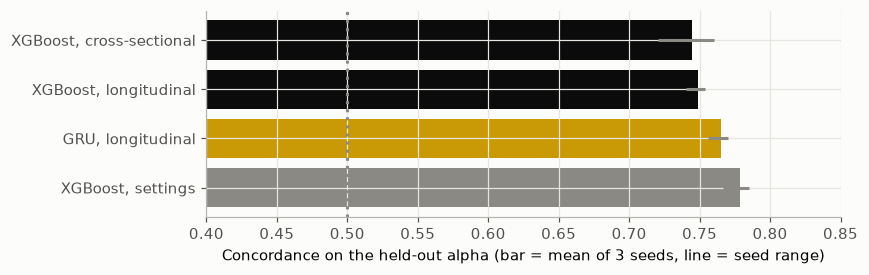

,alpha 0.5,alpha 1,alpha 2,mean,lowest seed,highest seed
model,,,,,,
"XGBoost, cross-sectional",0.729,0.676,0.828,0.744,0.720,0.760
"XGBoost, longitudinal",0.739,0.723,0.785,0.749,0.740,0.754
"GRU, longitudinal",0.777,0.727,0.791,0.765,0.756,0.770
"XGBoost, settings",0.725,0.808,0.802,0.778,0.766,0.785


In [17]:
import torch
torch.set_num_threads(1)


def aft_loss(mu, log_sigma, y, grokked):
    # Log-normal AFT loss: the density for runs that grokked, the chance of a later step for runs that did not.
    z = (y - mu) / log_sigma.exp()
    normal = torch.distributions.Normal(0.0, 1.0)
    return -(grokked * (normal.log_prob(z) - log_sigma) + (1 - grokked) * torch.log(normal.cdf(-z) + 1e-12)).mean()


class GRU(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = torch.nn.GRU(3, 16, batch_first=True)
        self.head = torch.nn.Linear(16, 1)
        self.log_sigma = torch.nn.Parameter(torch.zeros(()))

    def forward(self, x):
        return self.head(self.gru(x)[1][-1]).squeeze(-1)


def train_gru(z, train, seed):
    # Fit on 80% of the training cells and keep the weights with the lowest loss on the other 20%.
    fit, val = validation_split(train, seed)
    y = (log_T - log_T[train].mean()) / log_T[train].std()
    Z, Y, E = (torch.tensor(np.asarray(v), dtype=torch.float32) for v in (z, y, data['grokked']))
    torch.manual_seed(seed)
    net = GRU()
    opt = torch.optim.Adam(net.parameters(), lr=1e-2, weight_decay=1e-4)
    best = (np.inf, None, 0)
    for epoch in range(1, 801):
        opt.zero_grad()
        aft_loss(net(Z[fit]), net.log_sigma, Y[fit], E[fit]).backward()
        opt.step()
        if epoch % 10 == 0:
            with torch.no_grad():
                loss = aft_loss(net(Z[val]), net.log_sigma, Y[val], E[val]).item()
            if loss < best[0]:
                best = (loss, copy.deepcopy(net.state_dict()), epoch)
    net.load_state_dict(best[1])
    return net, best[2]


settings = np.column_stack([np.log(data['width']), np.log10(data['eta_kappa'].where(data['eta_kappa'] > 0, 1e-6))])     # weight decay 0 sits at 1e-6
alphas = sorted(data['alpha'].unique())
hist_scores, epochs = {}, {}
for seed in range(3):
    preds = {name: np.zeros(len(data)) for name in ['XGBoost, longitudinal', 'GRU, longitudinal', 'XGBoost, settings']}
    for a in alphas:
        train, test = (data['alpha'] != a).to_numpy(), (data['alpha'] == a).to_numpy()
        z = (history - history[train].mean(axis=(0, 1))) / history[train].std(axis=(0, 1))
        for name, X in [('XGBoost, longitudinal', z.reshape(len(z), -1)), ('XGBoost, settings', settings)]:
            booster, _ = tuned_xgb(X, train, seed)
            preds[name][test] = booster.predict(xgb.DMatrix(X[test]))
        net, epochs[seed, a] = train_gru(z, train, seed)
        with torch.no_grad():
            preds['GRU, longitudinal'][test] = net(torch.tensor(z[test], dtype=torch.float32)).numpy()
    for name, p in preds.items():
        hist_scores[name, seed] = {f'alpha {a:g}': concordance_index(data.loc[data['alpha'] == a, 'T'], p[data['alpha'] == a], data.loc[data['alpha'] == a, 'grokked'])
                                   for a in alphas}

hist_scores = pd.DataFrame(hist_scores).T
hist_scores['mean'] = hist_scores.mean(axis=1)
cross = seed_scores.iloc[:3].copy()
cross.index = pd.MultiIndex.from_product([['XGBoost, cross-sectional'], range(3)])
compare = pd.concat([cross, hist_scores]).rename_axis(['model', 'seed'])
summary = compare.groupby('model', sort=False).mean()
summary['lowest seed'] = compare['mean'].groupby('model', sort=False).min()
summary['highest seed'] = compare['mean'].groupby('model', sort=False).max()
print('GRU epochs chosen by early stopping:', sorted(epochs.values()))

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.barh(summary.index, summary['mean'], color=[INK, INK, KERNEL_COLOURS['R_t'], GREY])
ax.errorbar(summary['mean'], range(len(summary)), xerr=[summary['mean'] - summary['lowest seed'], summary['highest seed'] - summary['mean']],
            fmt='none', ecolor=GREY)
ax.axvline(0.5, color=GREY, linestyle=':')
ax.set_xlim(0.4, 0.85)
ax.invert_yaxis()
ax.set_xlabel('Concordance on the held-out alpha (bar = mean of 3 seeds, line = seed range)')
plt.tight_layout()
plt.show()
summary.round(3)

**Takeaway**
- The GRU on the longitudinal covariates scores 0.765 (seeds 0.756 to 0.770). XGBoost on the cross-sectional covariates scores 0.744 over the same 3 seeds (0.720 to 0.760). The gain of 0.02 is about half the seed spread of XGBoost.
- The GRU gains on `alpha` 0.5 (0.777 against 0.729) and `alpha` 1 (0.727 against 0.676), and loses on `alpha` 2 (0.791 against 0.828).
- XGBoost on the longitudinal covariates scores 0.749, close to its cross-sectional score. Trees treat the 75 values as unrelated features, while the GRU reads them in time order.
- Early stopping chose between 60 and 290 epochs. Each fold needs its own number, so a fixed number of epochs would overfit some folds.
- XGBoost on width and weight decay alone scores 0.778, higher than every kernel model. Much of what the kernel statistics predict about a new `alpha` is also in the settings. Notebook 4 (Part 7) finds the same among grokked runs.
- So the time structure of the kernel statistics helps a little, and a recurrent model can use it. The settings remain the stronger predictor. Ranking the seeds within each cell would test whether the longitudinal covariates carry anything beyond the settings.

## Summary

| Question | Answer |
| --- | --- |
| Does any one statistic predict a held-out `alpha`? | No. Each scores 0.50 to 0.55 on average. |
| Are the statistics associated with grokking time? | Yes. All three are associated with earlier grokking, and the cell bootstrap ranges exclude 0. |
| Do interactions matter? | Yes for this question, which includes censored runs. $z_A z_S$ and $z_A z_R$ lift the held-out score from 0.550 to 0.631. Alignment speeds grokking most when the kernel has rotated and when it has grown little. Notebook 4 shows that the gain comes from separating runs that grok from runs that never do. |
| Does a non-linear model find more? | Yes. XGBoost scores 0.737 on average over 5 seeds. Choosing its hyperparameters on a validation set did not raise this above the earlier fixed settings. |
| What shape is it? | `S_t` has an interior optimum near 0.7 to 1.0. `R_t` and `A_t` lower the predicted step up to a point and then level off. |
| Is the kernel series autocorrelated, and does its history help? | It is strongly autocorrelated. A GRU on the longitudinal covariates scores 0.765, about 0.02 above XGBoost on the cross-sectional covariates. |
| Do the kernel statistics beat the settings? | No. XGBoost on width and weight decay alone scores 0.778. |

## Conclusion

Read before any run groks, the kernel statistics rank runs from a held-out `alpha` well above chance. A linear model finds little of this. The relation is non-linear, and XGBoost reaches about 0.74. A GRU that reads the history of the statistics up to $t^*$ gains about 0.02 more.

The settings are a stronger predictor. A flexible model of width and weight decay alone reaches 0.778. A linear AFT on the same settings reaches only 0.549 (notebook 2), so comparing the kernel models with 0.549 overstates what the kernel adds. Notebook 2 showed that, inside one cell, only `S_t` tells seeds apart. Two fair next tests are to hold out one weight decay level at a time and to rank the seeds within each cell.